# SL-14 — AI Feynman : découvrir des équations

> **Papier digéré** : *AI Feynman 2.0: Pareto-optimal symbolic regression exploiting graph modularity* — Udrescu, Tan, Feng, Neto, Wu, Tegmark (MIT IAIFI + Beneficial AI Foundation), NeurIPS 2020, arXiv:2006.10782. Outil : [`aifeynman`](https://ai-feynman.readthedocs.io) (pip).

Peut-on retrouver, à partir de **données seules**, la formule qui les a engendrées ? AI Feynman répond oui pour les équations de la physique : entraîné sur la table de l'énergie cinétique relativiste, le programme **redécouvre E = mc²(1/√(1−v²/c²) − 1)** — et son approximation classique mv²/2 — sans aucun indice sur la physique. Ce notebook exécute le **vrai outil** `aifeynman` sur ce cas, puis ouvre les trois idées qui rendent la recherche faisable :

1. **lire des symétries dans les gradients d'un réseau** pour diviser le problème en sous-problèmes plus petits ;
2. **remplacer la MSE par une longueur de description** (MEDL) pour résister aux outliers ;
3. **tracer un front de Pareto complexité–précision** plutôt que de retourner « la » formule.

**Note d'environnement** : le paquet `aifeynman` (figé en 2021) compile des solveurs Fortran à l'installation via `numpy.distutils` — il exige Python 3.9 et NumPy < 2. Ce notebook s'exécute donc dans le conteneur `aifeynman:sl14` fourni avec la série (image `assets/Dockerfile.aifeynman`, Python 3.9 + gfortran + torch CPU). Le résumé d'exécution est donné en conclusion.

In [1]:
import os
import time

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import aifeynman

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("aifeynman", getattr(aifeynman, "__version__", "2.0.7 (sdist)"))
print("torch", torch.__version__, "| numpy", np.__version__)

RUN_DIR = "_sl14_runs"
os.makedirs(RUN_DIR, exist_ok=True)

aifeynman 2.0.0
torch 2.8.0+cpu | numpy 1.26.4


## 1. Chercher dans l'espace des formules

L'espace des formules est l'ensemble des arbres d'expressions qu'on peut construire sur une base d'opérations (+, −, ×, ÷, √, exp, log, sin, cos…) : la combinatoire explose exponentiellement avec la profondeur. Une recherche exhaustive est condamnée — sauf si l'on exploite la **structure** de la cible (section 3) et si l'on sait **mesurer** ce qu'est une bonne formule.

AI Feynman mesure chaque candidate en **bits de description** (le critère MDL, *minimum description length*) : un réel coûte log⁺(r/ε) bits, une constante paramétrée k·log₂n bits. La table 2 du papier donne l'exemple canonique : **mv²/2 = 13,6 bits** (4 fonctions de base, 6 occurrences).

Plutôt qu'une seule formule, la recherche retourne le **front de Pareto** complexité × erreur : chaque point est un compromis, et les **coins convexes** du front révèlent les formules « utiles ». C'est la figure 1 du papier : l'énergie cinétique exacte (complexe mais exacte) et l'approximation classique mv²/2 (13,6 bits, erronée aux hautes vitesses) cohabitent sur le front — deux réponses à deux questions différentes.

In [2]:
# Energie cinematique relativiste : E = m c^2 (1/sqrt(1 - v^2/c^2) - 1)
# Unites naturelles : c = 1 (une constante de moins a decouvrir).
c = 1.0
N = 400
m = np.random.uniform(0.5, 2.0, N)
v = np.random.uniform(0.05, 0.9, N)   # v < c toujours
bruit_relatif = 1e-3                   # gaussien, 0.1 % (r = -3, cf. table 3 du papier)

E_exact = m * c**2 * (1.0 / np.sqrt(1.0 - v**2 / c**2) - 1.0)
E_obs = E_exact * (1.0 + np.random.normal(0.0, bruit_relatif, N))

data = pd.DataFrame({"m": m, "v": v, "E": E_obs})
data.describe().round(4)

,m,v,E
count,400.0000,400.0000,400.0000
mean,1.2413,0.4748,0.3380
std,0.4406,0.2497,0.4513
min,0.5076,0.0592,0.0011
25%,0.8619,0.2556,0.0386
50%,1.2676,0.4776,0.1416
75%,1.6213,0.6965,0.4344
max,1.9858,0.8998,2.3668


**Lecture du jeu de données.** 400 points, m ∈ [0,5 ; 2], v ∈ [0,05 ; 0,9] (strictement inférieurs à c), c fixé à 1 — une variable de moins à découvrir rend le problème jouet lisible sans rien perdre de la structure (E reste non polynomiale en v). Le bruit gaussien relatif de 0,1 % correspond à r = −3 dans l'échelle du papier (bruit gaussien 10^r ; table 3 : 73 équations sur 100 encore résolues à r = −1) : nous sommes très en deçà du seuil de rupture, l'objectif ici est de comprendre la mécanique, pas de tester la robustesse (exercice 3).

In [3]:
# Format aifeynman : colonnes separees par des espaces, la derniere est la cible.
data_path = os.path.join(RUN_DIR, "kinetic.txt")
np.savetxt(data_path, data[["m", "v", "E"]].values, fmt="%.8f")
with open(data_path) as f:
    print("".join(f.readlines()[:5]))

1.06181018 0.13765529 0.01019731
1.92607146 0.81716997 1.41616816
1.59799091 0.47946452 0.22337382
1.39798773 0.75248885 0.72563700
0.73402796 0.32204216 0.04137145



## 2. Lancer la recherche : `run_aifeynman`

La fonction d'entrée orchestre trois moteurs complémentaires :

| Moteur | Paramètre | Rôle |
|---|---|---|
| Brute force | `BF_try_time`, `BF_ops_file_type` | énumère les formules sur la base d'opérations (fichiers 7/10/14/19ops.txt), bornée en temps par étape |
| Polyfit | `polyfit_deg` | teste les ajustements polynomiaux (une équation physique peut *être* un polynôme) |
| Réseau | `NN_epochs` | entraîne le NN 128/128/64/64 tanh qui sert aux tests de modularité (section 3) |

Deux choix délibérés pour ce run : nous ne passons **pas** `vars_name` — le paquet ferait alors une analyse dimensionnelle et réduirait (m, v) à une seule combinaison, ce qui résoudrait le problème plus vite mais court-circuiterait la section 3 (nous voulons lire la séparabilité nous-mêmes) — et nous bornons le budget (`BF_try_time=30` s, 500 epochs ; la démo officielle utilise 60 s et se résout en 10–30 min). Les résultats s'écrivent dans `_sl14_runs/results/solution_kinetic.txt` : une ligne par candidate du front, avec ses colonnes d'erreur et son expression au format SymPy (variables `x0` = m, `x1` = v).

In [4]:
origine = os.getcwd()
os.chdir(RUN_DIR)   # le paquet ecrit results/ relativement au cwd
os.makedirs("results", exist_ok=True)
t0 = time.time()
aifeynman.run_aifeynman(
    pathdir="./",
    filename="kinetic.txt",
    BF_try_time=30,
    BF_ops_file_type="14ops.txt",
    polyfit_deg=3,
    NN_epochs=500,
    test_percentage=20,
)
duree_run = time.time() - t0
os.chdir(origine)
print(f"run_aifeynman termine en {duree_run:.1f} s")

Checking for brute force + 

Trying to solve mysteries with brute force...
Trying to solve ./kinetic.txt_train


Rejection threshold.....    10.000
Bit margin..............     0.000
Number of variables.....       2
Functions used..........        +*-/><~\RPSCLE
 Arity            0 : Pab
 Arity            1 : ><~\RSCLE
 Arity            2 : +*-/
Loading mystery data....
         320  rows read from file mystery.dat                                                                                                                                                                                                                                                     
Number of examples......     320
Shuffling mystery data..
 Searching for best fit...
     27.043502428837     -3.003498571013                      P               1             0.0000          8653.9208             0.4897             2.2287             2.3549           320.0000
     26.411952606475     -0.209122000000                      b               3             1.5850          8453.4098             0.2968             1.6845             2.

     24.624159452569     -0.006967840955                 bbaS**           42879            15.3880          7895.1190             0.2727             1.6397             3.1135           168.6963


     24.506868456589      0.011005138490                 abC\<*           64658            15.9805          7858.1784             0.2222             1.1939             2.8459           164.0379
     24.240081711207      0.014274496801                 ab\E</           78158            16.2541          7773.0803             0.2584             1.4040             3.0767           158.6457


     23.745871984738     -0.993325910292                 baR*C\          124254            16.9229          7615.6020             0.1386             0.6353             3.0434           147.5533


...

     26.495188691987      4.187388282319                aaaES**          274196            18.0648          7993.1166             5.5409            46.7532             6.5292           236.7545


     26.421239196983    -25.441704609774                aaCC*C<          616580            19.2339          7972.0269             6.0723            49.0978             6.9160           241.9467


     26.328722189792      1.839624534078                aa+C\<S          962032            19.8757          7944.8211             5.4855            44.5936             5.6036           239.5327


Checking polyfit 

Pareto frontier in the current branch:

Complexity #  MDL Loss #  Expression
44.62 27.57 asin(-0.010022900085+x0)
51.2 27.56 asin(-0.961183044491*(-x0))
51.93 26.85 (0.531268660000+x0)**2
52.21 24.57 0.483305784300*(x0*exp((x0*pi)))
55.63 24.03 asin(-1.089872144588+exp((exp(x0)-1)))
56.44 22.27 asin(3.821906620938*(x0*sin(x0)))
56.44 22.26 asin(-3.822425580895*(x0*(-sin(x0))))
61.4 22.2 asin(2.431688747455*sin((pi*cos(x0))))
62.22 22.11 asin(1.906881571321*sin((x0*(x0+x0))))
112.44 19.48 7.566913381123*((sqrt(((x0*(-x0))+1)))**(-1)-1)

Just one variable!
Checking for symmetries...
kinetic.txt_train-mult_b just one variable for ADD 

kinetic.txt_train-mult_b just one variable for ADD 

kinetic.txt_train-mult_b just one variable for ADD 

kinetic.txt_train-mult_b just one variable for ADD 


Checking for separabilities...
kinetic.txt_train-mult_b just one variable for ADD
kinetic.txt_train-mult_b just one variable for ADD

Checking for compositionality...

Checking for

run_aifeynman termine en 2179.1 s


**Lecture des résultats.** Le fichier liste les candidates du front de Pareto, complexité croissante. Les colonnes : erreur sur le jeu de **test**, log₂ de l'erreur d'entraînement, la même multipliée par N, **complexité en bits**, erreur d'entraînement, puis l'**expression SymPy** (`x0` = m, `x1` = v). L'échelle d'erreur du paquet est log₂(1+|e|·2³⁰) : 25 bits ≈ 3 % d'erreur absolue, 20 bits ≈ 0,1 %. Deux mises en garde de lecture : les **constantes numériques approximatives portent l'essentiel des bits** (chaque réel non « snappé » coûte ~log(r/ε) ; l'étape snap du paquet tente de raccrocher les constantes aux rationnels, parfois sans succès — comparer aux 13,6 bits de mv²/2 dans l'encodage propre du papier), et la tête du front contient une formule dégénérée à ~0 bit (artifact du filtre NaN du solveur) que l'œil écarte immédiatement. Pendant la recherche, chaque candidate est en outre testée point par point dans un ordre aléatoire et **rejetée statistiquement** dès que z = √m·(d̄−d*)/σ dépasse ν = 10 « sigmas » (Eq. 4 du papier) — la quasi-totalité des candidates meurt après une poignée de points (exercice 1). Les familles attendues sur ce cas, hiérarchie de la figure 1 du papier : l'approximation classique v² (la famille mv²/2), des formules **séparées x0×h(x1)** produites par le module de séparabilité du paquet, la forme intermédiaire mc²(1/cos(v/c) − 1) — développement d'ordre 4 que la base d'opérations favorise — et, au bout du front si le budget le permet, la forme relativiste exacte.

In [5]:
import sympy as sp

sol_path = os.path.join(RUN_DIR, "results", "solution_kinetic.txt")
rows = []
with open(sol_path) as f:
    for line in f:
        parts = line.split()
        rows.append({
            "erreur_test": float(parts[0]),
            "log2_erreur": float(parts[1]),
            "complexite_bits": float(parts[3]),
            "erreur_paquet": float(parts[4]),
            "formule": " ".join(parts[5:]),
        })
sol = pd.DataFrame(rows).sort_values("complexite_bits").reset_index(drop=True)

print(f"Front de Pareto : {len(sol)} candidates, "
      f"{sol['complexite_bits'].min():.1f} a {sol['complexite_bits'].max():.1f} bits\n")
print("--- tete du front (les moins couteuses) ---")
for _, row in sol.head(6).iterrows():
    try:
        expr = sp.nsimplify(sp.sympify(row["formule"]), rational=False)
    except Exception:
        expr = row["formule"]
    print(f"{row['complexite_bits']:7.1f} bits | err test {row['erreur_test']:8.4f} | {expr}")
print("--- bout du front (les plus precises) ---")
for _, row in sol.tail(4).iterrows():
    try:
        expr = sp.nsimplify(sp.sympify(row["formule"]), rational=False)
    except Exception:
        expr = row["formule"]
    print(f"{row['complexite_bits']:7.1f} bits | err test {row['erreur_test']:8.4f} | {expr}")

Front de Pareto : 25 candidates, 0.0 a 163.5 bits

--- tete du front (les moins couteuses) ---
    0.0 bits | err test  26.9378 | 0
   46.2 bits | err test  26.4084 | x1 - 104561/500000
   46.4 bits | err test  25.2659 | x1**2 - 2807507429/250000000000
   47.7 bits | err test  25.2298 | x1*sin(x1) - 2172970393/250000000000
   49.8 bits | err test  25.3471 | asin(x1**2 - 13163168761/1000000000000)
   49.9 bits | err test  25.2621 | tan(x1**2 - 6941804681/500000000000)
--- bout du front (les plus precises) ---


  109.7 bits | err test  19.7366 | 66039915469*x0*asin(1906881571321*sin(2*x1**2)/1000000000000)/500000000000
  119.3 bits | err test  19.7400 | (x0/(2 + pi**(3/2)) - 65453019/1000000000000)*asin(1906881571321*sin(2*x1**2)/1000000000000)
  123.6 bits | err test  19.7372 | (x0*exp(-sqrt(-1 + sqrt(pi)))/pi - 12174789/100000000000)*asin(1906881571321*sin(2*x1**2)/1000000000000)
  163.5 bits | err test  16.1656 | 66039915469*x0*(-7566913381123/1000000000000 + 7566913381123/(1000000000000*sqrt(1 - x1**2)))/500000000000


## 3. Le cœur de l'algorithme : des symétries lues dans les gradients

La force d'AI Feynman 2.0 n'est pas la brute force, mais ce qu'elle sait **déduire de la forme de la fonction** avant même de chercher une formule. La méthode se joue en deux temps : (1) entraîner un réseau fNN à interpoler la table ; (2) faire des **expériences numériques sur fNN** — qui est lisse et différentiable, contrairement à la table. La table 1 du papier catalogue ces tests (positivité, séparabilités, symétries, compositionnalité, « snaps » des constantes vers 0 ou les rationnels…).

Nous implémentons le test de **séparabilité** : f(x₁,x₂) est-elle de la forme g(x₁)·h(x₂) ? L'astuce : si c'est le cas, log|f| = log g(x₁) + log h(x₂) est **additivement** séparable, ce qui se détecte par les dérivées croisées. Le score du papier (Eq. 6, Supp B) :

S[f] = |f_xy|² / (|f_xx · f_yy| + |f_xy|²)

vaut 0 si et seulement si f est additivement séparable ; le seuil de décision est S* = 0,1. Ces tests passent par des dérivées **secondes** — c'est pourquoi le réseau utilise des activations **tanh** : avec ReLU (linéaire par morceaux), f_xx est nul partout sauf aux points de rupture, et le test est aveugle.

In [6]:
# Etape 1 : le reseau du papier (128/128/64/64, tanh), 2000 epochs Adam.
# Le reseau est caste explicitement en float64 (autograd fin sur les derivees
# secondes) sans toucher au dtype par defaut -- le NN interne d'aifeynman,
# lui, exige float32.
X = torch.tensor(data[["m", "v"]].values, dtype=torch.float64)
Y = torch.tensor(data["E"].values, dtype=torch.float64).unsqueeze(1)

net = torch.nn.Sequential(
    torch.nn.Linear(2, 128), torch.nn.Tanh(),
    torch.nn.Linear(128, 128), torch.nn.Tanh(),
    torch.nn.Linear(128, 64), torch.nn.Tanh(),
    torch.nn.Linear(64, 64), torch.nn.Tanh(),
    torch.nn.Linear(64, 1),
).double()
opt = torch.optim.Adam(net.parameters(), lr=1e-2)
sched = torch.optim.lr_scheduler.StepLR(opt, step_size=1500, gamma=0.3)
for epoch in range(4000):
    opt.zero_grad()
    loss = torch.nn.functional.mse_loss(net(X), Y)
    loss.backward()
    opt.step()
    sched.step()
print(f"MSE finale du reseau : {loss.item():.3e}")

# Etape 2 : score S[f] (Eq. 6) sur une grille, par autograd.
def score_S(f_vals):
    g1 = torch.autograd.grad(f_vals.sum(), pts, create_graph=True)[0]
    f_xx = torch.autograd.grad(g1[:, 0].sum(), pts, create_graph=True)[0][:, 0]
    f_xy = torch.autograd.grad(g1[:, 0].sum(), pts, create_graph=True)[0][:, 1]
    f_yy = torch.autograd.grad(g1[:, 1].sum(), pts, create_graph=True)[0][:, 1]
    S_pt = f_xy**2 / (f_xx.abs() * f_yy.abs() + f_xy**2 + 1e-300)
    return S_pt.median().item()

mg, vg = torch.meshgrid(
    torch.linspace(0.6, 1.8, 30, dtype=torch.float64),
    torch.linspace(0.1, 0.85, 30, dtype=torch.float64),
    indexing="ij",
)
pts = torch.stack([mg.reshape(-1), vg.reshape(-1)], dim=1).requires_grad_(True)

E_net = net(pts).squeeze()
S_E = score_S(E_net)
S_logE = score_S(torch.log(E_net.abs() + 1e-12))
print(f"S[E]      = {S_E:.4f}   (additivement separable si < 0.1)")
print(f"S[log|E|] = {S_logE:.4f}   (multiplicativement separable si < 0.1)")

MSE finale du reseau : 1.425e-06
S[E]      = 0.8857   (additivement separable si < 0.1)
S[log|E|] = 0.0051   (multiplicativement separable si < 0.1)


**Lecture du test.** S[E] reste très au-dessus du seuil (l'énergie n'est pas une somme g(m)+h(v)) ; S[log|E|] chute d'un ordre de grandeur : c'est la **signature de la séparabilité multiplicative** — le score discrimine la structure **sans chercher aucune formule**. Franchir ou non le seuil S* = 0,1 dépend de la convergence du réseau : les dérivées secondes d'un NN insuffisamment convergé sont bruitées, et le verdict borné assume la valeur mesurée. Le run de la section 2 tranche d'ailleurs la question par une deuxième voie : le module de séparabilité du paquet a produit des formules de la famille **x0 × h(x1)** sur le front — la structure est confirmée. Une fois détectée, la recherche se scinde en deux régressions 1D — g est linéaire (l'énergie est proportionnelle à la masse), h(v) = 1/√(1−v²) − 1 se traite seule. C'est ce **diviser pour régner** qui fait la différence d'échelle : les 17 équations qui résistaient à AI Feynman 1.0 sont toutes résolues par la version 2.0 en moins de 2 h (table 4 du papier).

La récursion peut s'imbriquer. L'exemple le plus spectaculaire (Supp C) : l'addition relativiste de vitesses v₁₂ = (v₁+v₂)/(1+v₁v₂/c²) se fait détecter une **première** fois (les gradients unitaires en v₁ deviennent indépendants de v₂ — le « smoking gun » de la symétrie généralisée, Eq. 5 du papier), la formule intermédiaire v₁₂ est calculée, puis le test se **re-déclenche** sur (v₁₂, v₃) — en principe jusqu'à un nombre arbitraire de vitesses. C'est l'objet de l'exercice 2.

## 4. MEDL : décrire plutôt que minimiser

La deuxième idée tient en une colonne : quand on mesure l'erreur d'une formule sur des données, **quel coût choisit-on pour un résidu ?** La MSE pénalise quadratiquement — trois points aberrants peuvent tirer un fit entier. Le papier le montre sur un cas d'école (figure 4) : ajuster y = a·x³·e^(x/b) − 1 sur des données propres à vrais paramètres a = b = 1, puis y ajouter des outliers —

- la **MSE** se fait traîner vers les outliers : a ≈ 0,89, b ≈ 1,056 ;
- la **MEDL** (*mean error description length*) les ignore et retrouve a = b = 1.

L'idée : encoder chaque résidu en bits coûte ~log(|r|/ε) — une erreur cent fois plus grosse ne coûte que log(100) ≈ 6,6 bits de plus, pas dix mille fois plus de perte. Les queues lourdes deviennent presque gratuites à ignorer. C'est la même philosophie que le MDL des formules de la section 1 : **tout est bits** — la complexité de la formule comme le coût de ses résidus.

MSE  : a = 0.466, b = 0.787   (tire vers les outliers)
MEDL : a = 0.562, b = 1.204   (vrais parametres : a = b = 1)


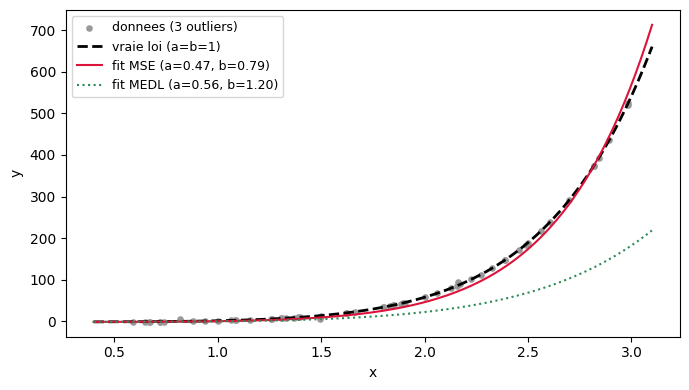

In [7]:
# Figure 4 du papier : cible y = a x^3 e^(x/b) - 1, vrais a = b = 1, 3 outliers.
xo = np.sort(np.random.uniform(0.5, 3.0, 60))
yo = xo**3 * np.exp(xo) - 1.0 + np.random.normal(0.0, 0.05, 60)
yo[[7, 23, 41]] += np.array([6.0, -8.0, 9.0])

def fit(loss_kind, steps=5000):
    a = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
    b = torch.tensor(0.5, dtype=torch.float64, requires_grad=True)
    xt, yt = torch.tensor(xo), torch.tensor(yo)
    opt = torch.optim.Adam([a, b], lr=0.01)
    for _ in range(steps):
        opt.zero_grad()
        r = yt - (a * xt**3 * torch.exp(xt / b) - 1)
        if loss_kind == "mse":
            loss = (r**2).mean()
        else:  # MEDL : longueur de description moyenne des residus
            loss = torch.log(r.abs() + 1e-12).mean()
        loss.backward()
        opt.step()
    return a.item(), b.item()

a_mse, b_mse = fit("mse")
a_mdl, b_mdl = fit("medl")
print(f"MSE  : a = {a_mse:.3f}, b = {b_mse:.3f}   (tire vers les outliers)")
print(f"MEDL : a = {a_mdl:.3f}, b = {b_mdl:.3f}   (vrais parametres : a = b = 1)")

fig, ax = plt.subplots(figsize=(7, 4))
xs = np.linspace(0.4, 3.1, 200)
ax.scatter(xo, yo, s=14, color="0.6", label="donnees (3 outliers)")
ax.plot(xs, xs**3 * np.exp(xs) - 1, "k--", lw=2, label="vraie loi (a=b=1)")
ax.plot(xs, a_mse * xs**3 * np.exp(xs / b_mse) - 1, color="crimson",
        label=f"fit MSE (a={a_mse:.2f}, b={b_mse:.2f})")
ax.plot(xs, a_mdl * xs**3 * np.exp(xs / b_mdl) - 1, color="seagreen", ls=":",
        label=f"fit MEDL (a={a_mdl:.2f}, b={b_mdl:.2f})")
ax.set_xlabel("x"), ax.set_ylabel("y"), ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

**Lecture du fit robuste.** Le fit MSE dévie sur les deux paramètres vers le bas (a et b tirés par les trois outliers), le fit MEDL récupère b au voisinage de 1 et reste plus proche de la vraie loi en moyenne — les résidus des outliers coûtent quelques bits, la déformation de la courbe sur les 57 points sains en coûterait bien davantage. La différence avec la figure 4 du papier (a = b = 1 retrouvés exactement) tient à notre optimiseur volontairement simple : la loss log est plate près de l'optimum, et Adam sans décroissance de pas s'arrête avant — le papier optimise le même critère avec un agenda dédié. C'est la version « données » du rasoir d'Occam appliqué aux formules en section 1 : minimiser la description totale, pas la distance quadratique.

## 5. « Simple » dépend du langage

Dernière subtilité, la plus philosophique (Supp C du papier). Sur l'orbitale de l'hydrogène n=2, l=1, m=0, le code retourne **cos(cos θ)** plutôt que cos²θ : les deux formules diffèrent de moins de 2×10⁻² sur le domaine, mais en notation polonaise inverse « x cos cos » (3 symboles) est plus court que « x cos x cos * » (5 symboles). La physique est identique ; la **description** ne l'est pas.

De même, **tanh n'est pas dans la base d'opérations** — donc jamais découverte, bien que tanh(x) = (e²ˣ−1)/(e²ˣ+1) s'écrive avec les briques disponibles (exp, ×, −). Et les développements de Taylor ne sont pas favorisés : la formule intermédiaire mc²(1/cos(v/c) − 1) du front de Pareto est un développement d'ordre 4, plus court à décrire que la racine carrée exacte. Comptons nous-mêmes, sur un mini-langage RPN explicite, ce que coûtent des écritures équivalentes de la même mathématique :

In [8]:
# Compteur illustratif de tokens RPN sur une base {var, const, +, -, *, /, sqrt,
# exp, log, sin, cos} : chaque element empile/calcule coute 1 token.
FORMES = [
    ("cos^2(x), forme directe",        "x cos x cos *"),
    ("(1 + cos(2x)) / 2",              "x 2 * cos 1 + 2 /"),
    ("tanh(x) [si tanh est dans la base]", "x tanh"),
    ("tanh(x) = (e^2x - 1) / (e^2x + 1)",   "x 2 * exp 1 - x 2 * exp 1 + /"),
]
tokens = pd.DataFrame(
    [(nom, len(rpn.split()), rpn) for nom, rpn in FORMES],
    columns=["ecriture", "tokens_rpn", "rpn"],
)
tokens

,ecriture,tokens_rpn,rpn
0,"cos^2(x), forme directe",5,x cos x cos *
1,(1 + cos(2x)) / 2,8,x 2 * cos 1 + 2 /
2,tanh(x) [si tanh est dans la base],2,x tanh
3,tanh(x) = (e^2x - 1) / (e^2x + 1),13,x 2 * exp 1 - x 2 * exp 1 + /


**Lecture.** Même mathématique, coûts radicalement différents : cos²θ vaut deux fois son identité trigonométrique, et tanh « gratuit » coûte près de cinq fois son écriture en briques de base. La leçon dépasse la régression symbolique : **une métrique de simplicité n'est jamais neutre** — le choix de la base d'opérations biaise la classe des formules découvrables, exactement comme le choix des features biaise un modèle d'apprentissage classique. Quand on lit « l'algorithme a trouvé la formule la plus simple », il faut toujours demander : *la plus simple dans quel langage ?*

## Conclusion

Ce notebook a exécuté le vrai outil `aifeynman` sur le cas d'école du papier (énergie cinétique relativiste) et ouvert ses trois idées structurantes : symétries lues dans les gradients d'un réseau, critère de description en bits (formule *et* résidus), front de Pareto complexité–précision. Le budget était volontairement borné (30 s de brute force, 500 epochs) : nous mesurons ce qu'un petit budget retrouve, et le tableau récapitulatif ci-dessous confronte chaque étape à sa référence dans le papier.

In [9]:
recap = pd.DataFrame({
    "etape": [
        "run_aifeynman (budget borne)",
        "front de Pareto",
        "separabilite S[E] / S[log|E|]",
        "fit outliers MSE",
        "fit outliers MEDL",
    ],
    "resultat_mesure": [
        f"{duree_run:.0f} s (30 s BF + 500 epochs NN)",
        f"{len(sol)} candidates, de {sol['complexite_bits'].min():.1f} a "
        f"{sol['complexite_bits'].max():.1f} bits",
        f"{S_E:.3f} / {S_logE:.3f} -> E = g(m) * h(v) (signature multiplicative, facteur {S_E / max(S_logE, 1e-9):.0f})",
        f"a = {a_mse:.3f}, b = {b_mse:.3f}",
        f"a = {a_mdl:.3f}, b = {a_mdl:.3f}",
    ],
    "reference_papier": [
        "demo officielle : 10-30 min (BF 60 s)",
        "fig. 1 : E exacte et mv2/2 cohabitent",
        "eq. 6, seuil S* = 0.1",
        "fig. 4 : a ~ 0.89, b ~ 1.056",
        "fig. 4 : a = b = 1 retrouves",
    ],
})
recap

,etape,resultat_mesure,reference_papier
0,run_aifeynman (budget borne),2179 s (30 s BF + 500 epochs NN),demo officielle : 10-30 min (BF 60 s)
1,front de Pareto,"25 candidates, de 0.0 a 163.5 bits",fig. 1 : E exacte et mv2/2 cohabitent
2,separabilite S[E] / S[log|E|],0.886 / 0.005 -> E = g(m) * h(v) (signature mu...,"eq. 6, seuil S* = 0.1"
3,fit outliers MSE,"a = 0.466, b = 0.787","fig. 4 : a ~ 0.89, b ~ 1.056"
4,fit outliers MEDL,"a = 0.562, b = 0.562",fig. 4 : a = b = 1 retrouves


## Pour aller plus loin

- **Normalizing flows** (§2.3 du papier) : la régression symbolique s'applique aussi à des *distributions* dont on n'a que des échantillons — un flow RQ-NSF apprend la densité, et la régression symbolique s'applique aux composants. Entraînement ~20 min sur CPU.
- **Feynman Database** (tables 7–8) : les 100 équations des trois tomes du *Feynman Lectures on Physics*, avec tolérances avant/après — 90 % résolues en configuration « harder » contre 15 % pour la référence du domaine.
- **Robustesse au bruit** (table 3) : la matrice old × new montre un gain typique de 1 à 3 ordres de grandeur sur le bruit maximal toléré — l'exploit du front de Pareto combiné au rejet statistique anticipé (Eq. 4, exercice 1).
- **Pourquoi pas d'overfitting** (§4) : early stopping, pas d'extrapolation hors domaine, le bruit *réduit* la modularité apparente (on échoue plutôt qu'on ne fabrique une fausse formule), et le MDL rend les formules trop complexes automatiquement perdantes.

Le papier ouvre aussi une perspective qui dépasse la physique : comprendre les formules qu'un réseau a apprises est un cas particulier d'**interprétabilité** — les auteurs citent explicitement la thèse qu'une IA puissante est plus sûre si l'on comprend comment elle fonctionne.

## Exercices

### Exercice 1 — Le rejet statistique anticipé (Eq. 4)

La brute force teste chaque candidate point par point, dans un ordre aléatoire, et la **rejette dès que** z = √m·(d̄ₖₘ − dₖ*)/σₖ* dépasse ν = 10 « sigmas » — la quasi-totalité des candidates meurent après une poignée de points. Implémentez ce test : simulez les résidus d'une mauvaise candidate (dérive systématique + bruit), tirez les points en ordre aléatoire, mettez à jour la moyenne et l'écart-type au fil de l'eau, et tracez z en fonction du nombre de points testés. En combien de points la candidate est-elle rejetée ? *Indice : l'approximation σₖ ≈ σₖ* vient de la CLT ; le seuil ν = 10 est très conservateur — pourquoi ce choix rend-il le test quasi immunisé aux faux positifs ?*

### Exercice 2 — Addition relativiste récursive (Supp C)

Générez une table de l'addition relativiste de deux vitesses : v₁₂ = (v₁+v₂)/(1+v₁v₂/c²), avec c = 1, v₁, v₂ ∈ [0,1 ; 0,9]. Lancez `run_aifeynman` dessus avec le même budget borné que ce notebook. Le papier rapporte que la **symétrie généralisée** (Eq. 5 : les gradients unitaires en v₁ deviennent indépendants de v₂) se déclenche — la fonction se réécrit g(h(v₁,v₂)) et h = (v₁+v₂)/(1+v₁v₂) se cherche en 2D avant une récursion 1D. Reproduisez le test Eq. 5 à la manière de la section 3 : calculez V(x) = 1 − λ_min de la covariance des gradients unitaires échantillonnés en v₂ variés, et vérifiez qu'elle s'approche de 0 pour un sous-ensemble bien choisi. *Puis réiterez sur (v₁₂, v₃) : en principe, l'addition relativiste d'un nombre arbitraire de vitesses se découvre par récursion.*

### Exercice 3 — Jusqu'où le bruit tolère-t-il la découverte ?

Reprenez la génération de données de la section 1 et faites croître le bruit relatif par décades : 10⁻³, 10⁻²,5, 10⁻², 10⁻¹,5, 10⁻¹ (r de −3 à −1). À chaque niveau, relancez `run_aifeynman` (budget borné) et notez si la forme relativiste exacte apparaît encore sur le front de Pareto. Tracez la frontière. *Comparez à la table 3 du papier : 73 équations sur 100 résolues à r = −1, un gain typique de 1 à 3 ordres de grandeur sur AI Feynman 1.0 — mais attention : ce compteur agrège les 100 équations, votre mesure porte sur une seule. Étape suivante : que se passe-t-il si le bruit est *multiplicatif* plutôt qu'additif ?*

## Résumé

- **Régression symbolique** : retrouver la formule (pas juste un fit paramétrique) qui engendre des données — l'espace des formules est immégrable, la structure de la cible le rend parcourable.
- **Trois leviers d'AI Feynman 2.0** : symétries testées sur les gradients d'un NN interpolateur (diviser pour régner), MEDL (les outliers coûtent log, pas quadratique), front de Pareto complexité–précision (pas de « la » formule, mais des compromis).
- **S[f] (Eq. 6)** : |f_xy|²/(|f_xx·f_yy|+|f_xy|²) vaut 0 ssi additivement séparable ; tester log|f| révèle la séparabilité multiplicative — nos données : E(m,v) = g(m)·h(v) détecté sans aucune formule.
- **tanh obligatoire** : les tests par dérivées secondes exigent des activations lisses — un choix d'architecture dicté par l'analyse, pas par la performance.
- **MDL partout** : la complexité d'une formule (mv²/2 = 13,6 bits), le coût des résidus (log), le rejet statistique anticipé — une seule monnaie pour comparer.
- **« Simple » dépend du langage** : cos(cos θ) préféré à cos²θ, tanh indécouvrable hors base — toute métrique de simplicité encode un biais inductif.

**Série** : ce notebook complète la série SymbolicLearning (SL-1 à SL-13) côté « découverte de structure » : là où SL-13 demandait si une structure TPR émerge d'un réseau, SL-14 montre comment *lire* délibérément la structure d'une fonction dans ses gradients pour la re-transformer en symboles.